<h1>Chapter 8-Estimating Linear Regression</h1>

<p>This structure is intentionally simple and is useful for learning how neural networks are
built. However, it is important to recognize an important limitation: Using a neural
network to estimate a simple linear regression is inefficient.</p>

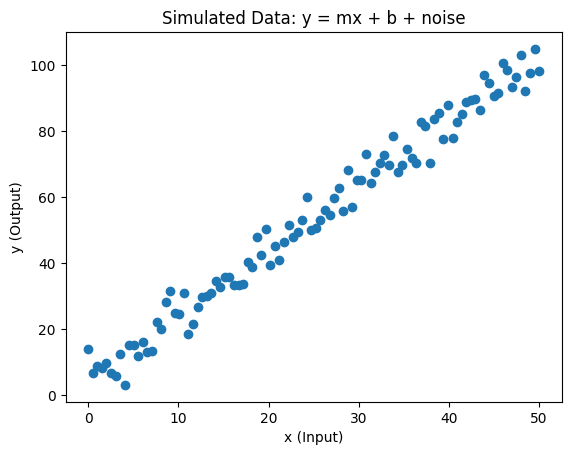


Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 4)                   │               8 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

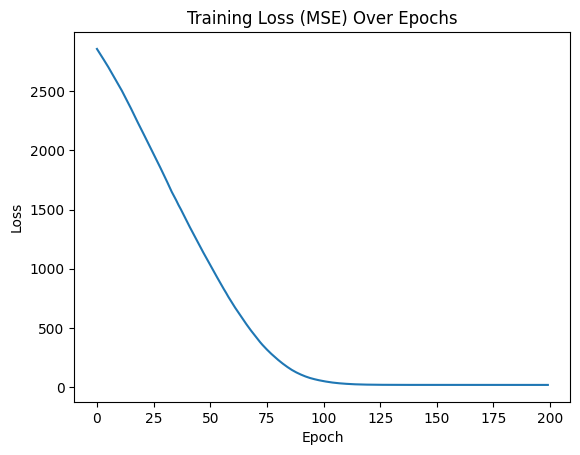

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


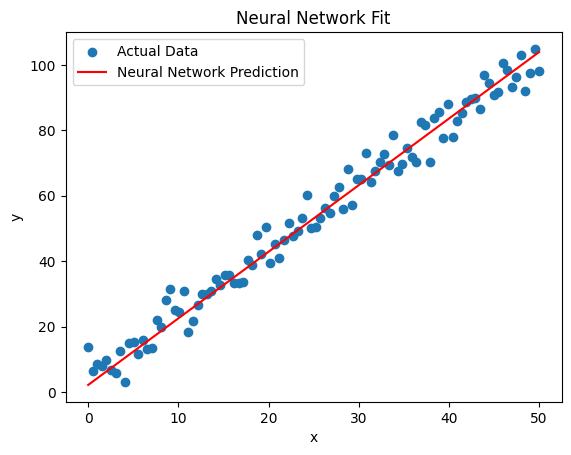

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Mean Squared Error: 18.299939964513943


In [1]:
# ----------------------------------------
# PART 1: IMPORT LIBRARIES
# ----------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Keras (modern usage)
from keras.models import Sequential
from keras.layers import Dense, Input

# Evaluation metric
from sklearn.metrics import mean_squared_error

# ----------------------------------------
# PART 2: CREATE SIMULATED DATA
# ----------------------------------------

# We simulate a simple linear relationship:
# y = mx + b + noise

m = 2   # slope
b = 3   # intercept

# Create 100 evenly spaced values between 0 and 50
x = np.linspace(0, 50, 100)

# Set a random seed so results are reproducible
np.random.seed(101)

# Create random noise (mean = 0, standard deviation = 4)
noise = np.random.normal(0, 4, size=len(x))

# Generate y values
y = m * x + b + noise

# ----------------------------------------
# PART 3: VISUALIZE THE DATA
# ----------------------------------------

plt.scatter(x, y)
plt.title("Simulated Data: y = mx + b + noise")
plt.xlabel("x (Input)")
plt.ylabel("y (Output)")
plt.show()

# ----------------------------------------
# PART 4: BUILD THE NEURAL NETWORK
# ----------------------------------------

# Create a sequential model
model = Sequential()

# Modern Keras: define input layer explicitly
model.add(Input(shape=(1,)))  # One input variable

# Hidden layers
model.add(Dense(4, activation='relu'))  # First hidden layer
model.add(Dense(4, activation='relu'))  # Second hidden layer

# Output layer (for regression)
model.add(Dense(1, activation='linear'))

# Compile the model
# - loss: Mean Squared Error (MSE)
# - optimizer: Adam (efficient training algorithm)
model.compile(loss='mse', optimizer='adam')

# Display model structure
print("\nModel Summary:")
model.summary()

# ----------------------------------------
# PART 5: TRAIN THE MODEL
# ----------------------------------------

# Train the model
# - epochs = number of times the model sees the data
history = model.fit(x, y, epochs=200, verbose=0)

# ----------------------------------------
# PART 6: PLOT THE LOSS FUNCTION
# ----------------------------------------

# Extract loss values
loss = history.history['loss']

# Create epoch index
epochs = range(len(loss))

# Plot loss over time
plt.plot(epochs, loss)
plt.title("Training Loss (MSE) Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ----------------------------------------
# PART 7: MAKE PREDICTIONS
# ----------------------------------------

# Create new input values
x_for_predictions = np.linspace(0, 50, 100)

# Predict output values
y_pred = model.predict(x_for_predictions)

# ----------------------------------------
# PART 8: VISUALIZE RESULTS
# ----------------------------------------

# Plot actual data
plt.scatter(x, y, label="Actual Data")

# Plot neural network predictions
plt.plot(x_for_predictions, y_pred, 'r', label="Neural Network Prediction")

plt.title("Neural Network Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# ----------------------------------------
# PART 9: EVALUATE MODEL PERFORMANCE
# ----------------------------------------

# Predict using original x values
y_pred_train = model.predict(x)

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred_train)

print("\nMean Squared Error:", mse)